# Online Haber Popülerliği — Analiz ve Modelleme
**Veri:** Mashable makaleleri (UCI, 2015) | **Hedef:** Bir makalenin viral olup olmayacağını tahmin et

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

sns.set_theme(style='whitegrid', palette='muted')
print('Hazır.')

Hazır.


## 1. Veriyi Yükle
`url` ve `timedelta` sütunları tahmin için işe yaramadığından kaldırılıyor.

In [2]:
df = pd.read_csv('Data/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()
df.drop(columns=['url', 'timedelta'], inplace=True)

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}  |  Missing: {df.isnull().sum().sum()}')
df.head(3)

Rows: 39,644  |  Columns: 59  |  Missing: 0


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


## 2. Feature Grupları
58 feature; içerik uzunluğu, medya (görsel/video), kanal, keyword kalitesi, zamanlama ve sentiment analizi gibi gruplardan oluşuyor. **Target:** `shares` — toplam paylaşım sayısı.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target: `shares`
Dağılım çok sağa çarpık — az sayıda viral makale ortalamayı yukarı çekiyor. Log transform dağılımı normale yaklaştırıyor.

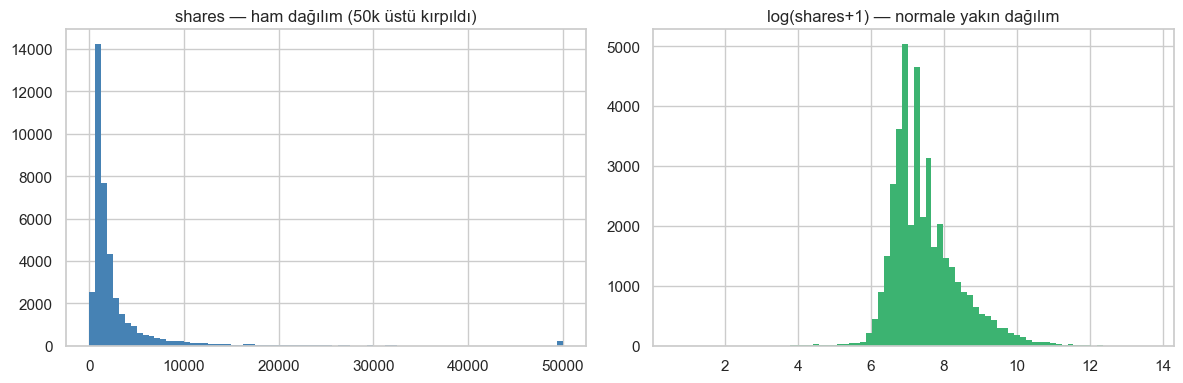

Çarpıklık — ham: 34.0  |  log: 1.03


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['shares'].clip(upper=50000), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('shares — ham dağılım (50k üstü kırpıldı)')

axes[1].hist(np.log1p(df['shares']), bins=80, color='mediumseagreen', edgecolor='none')
axes[1].set_title('log(shares+1) — normale yakın dağılım')

plt.tight_layout()
plt.show()
print(f"Çarpıklık — ham: {df['shares'].skew():.1f}  |  log: {np.log1p(df['shares']).skew():.2f}")

### 3.2 Kanala ve Güne Göre Paylaşım

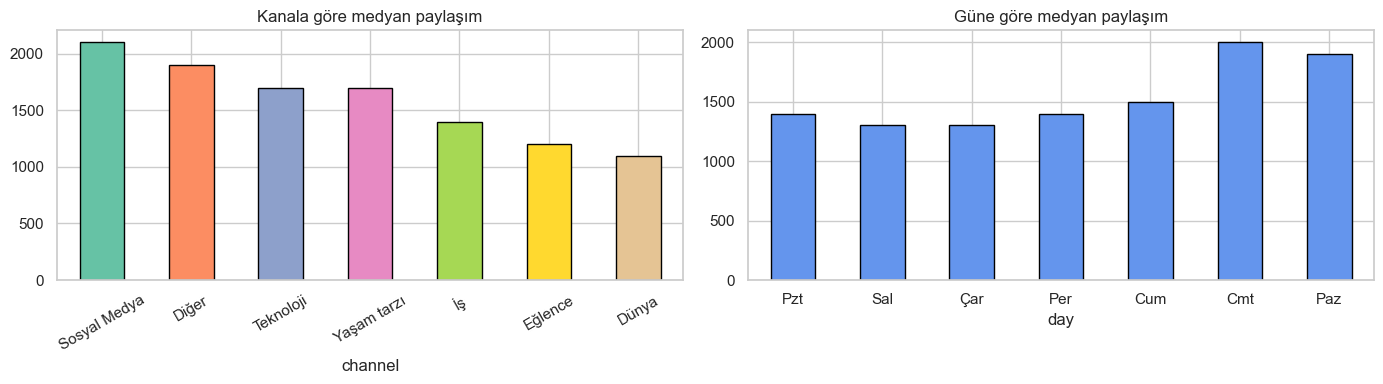

In [4]:
channel_map = {
    'data_channel_is_lifestyle':     'Yaşam tarzı',
    'data_channel_is_entertainment': 'Eğlence',
    'data_channel_is_bus':           'İş',
    'data_channel_is_socmed':        'Sosyal Medya',
    'data_channel_is_tech':          'Teknoloji',
    'data_channel_is_world':         'Dünya',
}
day_map = {
    'weekday_is_monday': 'Pzt', 'weekday_is_tuesday': 'Sal', 'weekday_is_wednesday': 'Çar',
    'weekday_is_thursday': 'Per', 'weekday_is_friday': 'Cum',
    'weekday_is_saturday': 'Cmt', 'weekday_is_sunday': 'Paz',
}

for col, label in channel_map.items():
    df.loc[df[col] == 1, 'channel'] = label
df['channel'] = df['channel'].fillna('Diğer')

for col, label in day_map.items():
    df.loc[df[col] == 1, 'day'] = label

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('channel')['shares'].median().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color=sns.color_palette('Set2', 7), edgecolor='black')
axes[0].set_title('Kanala göre medyan paylaşım')
axes[0].tick_params(axis='x', rotation=30)

day_order = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
df.groupby('day')['shares'].median().reindex(day_order).plot(
    kind='bar', ax=axes[1], color='cornflowerblue', edgecolor='black')
axes[1].set_title('Güne göre medyan paylaşım')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.3 Paylaşımla En Çok Korelasyon Gösteren Feature'lar

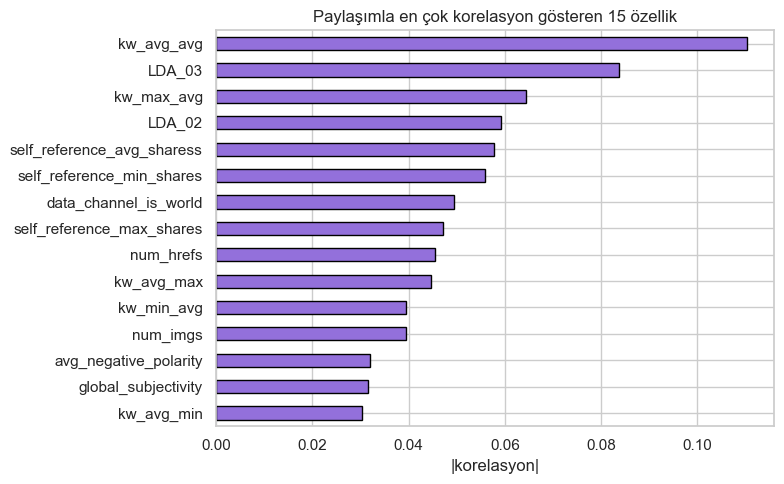

In [5]:
top_corr = (df.drop(columns=['channel', 'day'])
              .corr()['shares'].drop('shares')
              .abs().sort_values(ascending=False).head(15))

top_corr.sort_values().plot(kind='barh', figsize=(8, 5), color='mediumpurple', edgecolor='black')
plt.title('Paylaşımla en çok korelasyon gösteren 15 özellik')
plt.xlabel('|korelasyon|')
plt.tight_layout()
plt.show()

## 4. Preprocessing
- Target'ı `np.log1p` ile log transform et — sağa çarpık dağılımı normalize eder
- **%80 / %20 train-test split** (rastgele, `random_state=42`) — regression target'ı sürekli olduğu için stratified split uygulanmaz
- `StandardScaler` ile feature'ları ölçeklendir (ortalama=0, std=1)
- Model tahminleri değerlendirme öncesinde `np.expm1()` ile **orijinal ölçeğe geri dönüştürülür** (inverse transform), böylece RMSE gerçek paylaşım sayısı cinsinden yorumlanabilir

In [6]:
X     = df.drop(columns=['shares', 'channel', 'day'])
y_log = np.log1p(df['shares'])
y_raw = df['shares']

X_train, X_test, y_tr, y_te = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_te_raw = y_raw.loc[X_test.index]

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# PCA — varyansın %95'ini açıklayan bileşen sayısına indir
from sklearn.decomposition import PCA
pca_full = PCA().fit(X_tr_sc)
n95      = (pca_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1
pca      = PCA(n_components=n95, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)

print(f'Train: {X_tr_sc.shape[0]:,}  |  Test: {X_te_sc.shape[0]:,}  |  Feature: {X_tr_sc.shape[1]}')
print(f'PCA: {X_tr_sc.shape[1]} feature → {n95} component (varyansın %95\'i)')

Train: 31,715  |  Test: 7,929  |  Feature: 58
PCA: 58 feature → 36 component (varyansın %95'i)


## 5. Model Eğitimi ve Karşılaştırması

| Model | Açıklama |
|-------|----------|
| Linear Regression | Düz çizgi uydurur, basit ama yüzeysel |
| Random Forest | Çok sayıda karar ağacının ortalaması (bagging) |
| XGBoost / LightGBM / CatBoost | Her ağaç bir öncekinin hatasını düzeltir (boosting) |

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0),
    'LightGBM':          LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost':          CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0),
}

results = []
for name, model in models.items():
    for label, X_tr, X_te in [('No PCA', X_tr_sc, X_te_sc), (f'PCA ({n95})', X_tr_pca, X_te_pca)]:
        m = model.__class__(**model.get_params())
        m.fit(X_tr, y_tr)
        log_preds = m.predict(X_te)
        preds     = np.expm1(log_preds)   # inverse transform: log-scale → original shares
        rmse      = np.sqrt(mean_squared_error(y_te_raw, preds))
        # R² on log scale: model was trained/optimised in log space → fairer measure (~0.15)
        r2_log    = r2_score(y_te, log_preds)
        # R² on original scale: dominated by viral outliers → appears very low (~0.003)
        r2_orig   = r2_score(y_te_raw, preds)
        results.append({'Model': name, 'PCA': label, 'RMSE': rmse,
                        'R2_log': r2_log, 'R2_original': r2_orig})

df_res = pd.DataFrame(results)
no_pca = df_res[df_res['PCA'] == 'No PCA'].set_index('Model')

print("RMSE (original shares scale — lower is better):")
print(df_res.pivot(index='Model', columns='PCA', values='RMSE').to_string())
print()
print("R² on log scale  (model's training objective — use this as primary metric):")
print(no_pca['R2_log'].round(4).to_string())
print()
print("R² on original scale  (suppressed by viral outliers — informational only):")
print(no_pca['R2_original'].round(4).to_string())

RMSE (original shares scale — lower is better):
PCA                      No PCA      PCA (36)
Model                                        
CatBoost           10971.631922  11008.846289
LightGBM           10970.008748  10999.029439
Linear Regression  11000.686811  11094.905852
Random Forest      10993.460657  11030.159544
XGBoost            10972.228215  10998.698832

R² on log scale  (model's training objective — use this as primary metric):
Model
Linear Regression    0.1274
Random Forest        0.1544
XGBoost              0.1750
LightGBM             0.1759
CatBoost             0.1798

R² on original scale  (suppressed by viral outliers — informational only):
Model
Linear Regression   -0.0028
Random Forest       -0.0015
XGBoost              0.0023
LightGBM             0.0027
CatBoost             0.0024


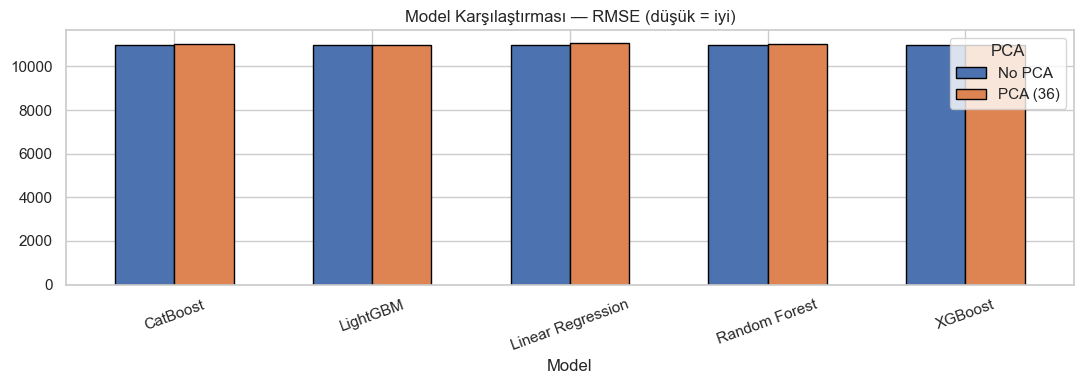

In [8]:
df_res.pivot(index='Model', columns='PCA', values='RMSE').plot(
    kind='bar', figsize=(11, 4), color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.6)
plt.title('Model Karşılaştırması — RMSE (düşük = iyi)')
plt.xticks(rotation=20)
plt.legend(title='PCA')
plt.tight_layout()
plt.show()

## 6. Cross-Validation (Tüm Modeller)
Tek bir split şanslı olabilir. **5-fold CV**, veriyi 5 parçaya bölerek modeli 5 kez değerlendirir ve ortalamasını alır.  
CV **yalnızca train seti üzerinde** çalışır — test seti hiç dokunulmadan kilitli kalır.  
Not: CV skoru log-ölçeğindedir (modelin optimize ettiği alan); RMSE tablosundaki ~10.970 ise orijinal shares cinsinden.

In [9]:
cv_results = []
for name, model in models.items():
    m = model.__class__(**model.get_params())
    scores = cross_val_score(
        m, X_tr_sc, y_tr, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_folds = -scores
    cv_results.append({'Model': name, 'Mean': rmse_folds.mean(), 'Std': rmse_folds.std(),
                       'Folds': rmse_folds.round(4).tolist()})
    print(f'{name:<22}  Mean: {rmse_folds.mean():.4f} ± {rmse_folds.std():.4f}  |  Folds: {np.round(rmse_folds, 4)}')

df_cv = pd.DataFrame(cv_results).set_index('Model')

Linear Regression       Mean: 1.4051 ± 1.0680  |  Folds: [0.8905 0.8635 0.8484 0.8821 3.5408]


Random Forest           Mean: 0.8629 ± 0.0136  |  Folds: [0.883  0.8562 0.8418 0.8662 0.8672]


XGBoost                 Mean: 0.8490 ± 0.0148  |  Folds: [0.867  0.8404 0.8249 0.8582 0.8544]


LightGBM                Mean: 0.8481 ± 0.0137  |  Folds: [0.8661 0.841  0.8258 0.8545 0.8531]


CatBoost                Mean: 0.8485 ± 0.0141  |  Folds: [0.8683 0.8407 0.8264 0.8533 0.8536]


## 7. Feature Importance
LightGBM'in hangi feature'lara en çok güvendiğini gösterir. **Gain** her feature'ın toplam bilgi katkısını ölçer.

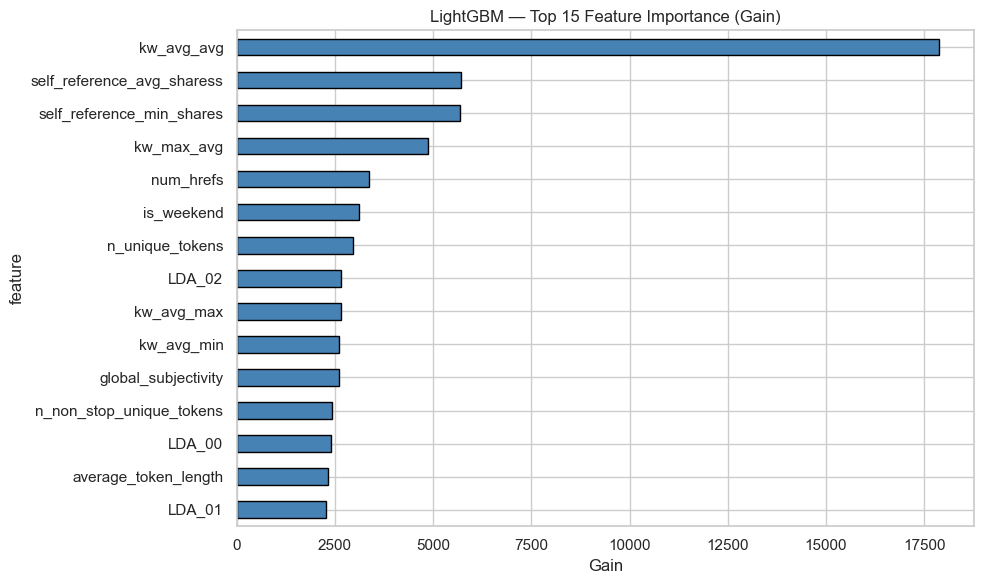

In [10]:
lgbm_final = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgbm_final.fit(X_tr_sc, y_tr)

fi = pd.DataFrame({
    'feature': X_train.columns,
    'gain':    lgbm_final.booster_.feature_importance('gain'),
}).sort_values('gain', ascending=False).head(15)

fi.sort_values('gain').plot(kind='barh', x='feature', y='gain',
    figsize=(10, 6), color='steelblue', edgecolor='black', legend=False)
plt.title('LightGBM — Top 15 Feature Importance (Gain)')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

## 8. Sonuçlar

**LightGBM neden iyi?** Veriler doğrusal değil; boosting doğrusal olmayan kalıpları yakalıyor.

**R² neden düşük (~0.15)?** Paylaşım sayısı kim ilk paylaştı, hangi influencer gördü gibi dataset'te olmayan faktörlere bağlı.

**En önemli feature'lar:** `kw_avg_avg`, `self_reference_avg_sharess`, `num_imgs`.

## 9. Binary Classification: Popüler mi? (Threshold = 1400)
Orijinal makale 1400 paylaşımı threshold olarak tanımlıyor — medyana yakın olduğu için class'lar yaklaşık dengeli (~%50/%50).

Popüler (>1400)     : 19,562  (49.3%)
Popüler değil (≤1400): 20,082  (50.7%)


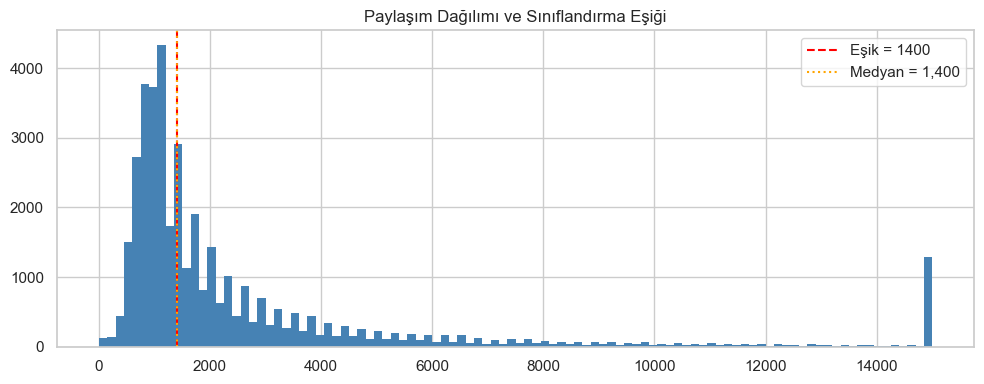

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

THRESHOLD = 1400
y_cls = (y_raw > THRESHOLD).astype(int)

print(f'Popüler (>1400)     : {y_cls.sum():,}  ({y_cls.mean()*100:.1f}%)')
print(f'Popüler değil (≤1400): {(1-y_cls).sum():,}  ({(1-y_cls).mean()*100:.1f}%)')

df['shares'].clip(upper=15000).hist(bins=100, color='steelblue', edgecolor='none', figsize=(10, 4))
plt.axvline(THRESHOLD, color='red', linestyle='--', label=f'Eşik = {THRESHOLD}')
plt.axvline(y_raw.median(), color='orange', linestyle=':', label=f"Medyan = {y_raw.median():,.0f}")
plt.title('Paylaşım Dağılımı ve Sınıflandırma Eşiği')
plt.legend()
plt.tight_layout()
plt.savefig('shares_threshold.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
y_cls_train = y_cls.loc[X_train.index]
y_cls_test  = y_cls.loc[X_test.index]

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost':             XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0),
    'LightGBM':            LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost':            CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0),
}

clf_results = []
for name, model in clf_models.items():
    model.fit(X_tr_sc, y_cls_train)
    proba = model.predict_proba(X_te_sc)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_te_sc)
    pred  = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_cls_test, pred)
    f1  = f1_score(y_cls_test, pred)
    auc = roc_auc_score(y_cls_test, proba)
    print(f'{name:<22}  Accuracy: {acc:.3f}  F1: {f1:.3f}  AUC: {auc:.3f}')
    clf_results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, '_proba': proba})

df_clf = pd.DataFrame(clf_results)

Logistic Regression     Accuracy: 0.651  F1: 0.635  AUC: 0.704


Random Forest           Accuracy: 0.662  F1: 0.656  AUC: 0.720


XGBoost                 Accuracy: 0.670  F1: 0.660  AUC: 0.732


LightGBM                Accuracy: 0.669  F1: 0.661  AUC: 0.731


CatBoost                Accuracy: 0.668  F1: 0.661  AUC: 0.734


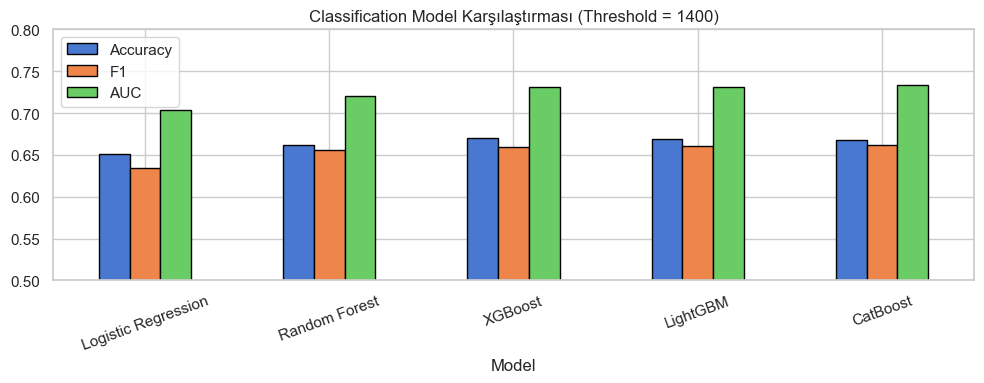

In [13]:
df_clf[['Model', 'Accuracy', 'F1', 'AUC']].set_index('Model').plot(
    kind='bar', figsize=(10, 4), edgecolor='black')
plt.title('Classification Model Karşılaştırması (Threshold = 1400)')
plt.xticks(rotation=20)
plt.ylim(0.5, 0.8)
plt.tight_layout()
plt.savefig('clf_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

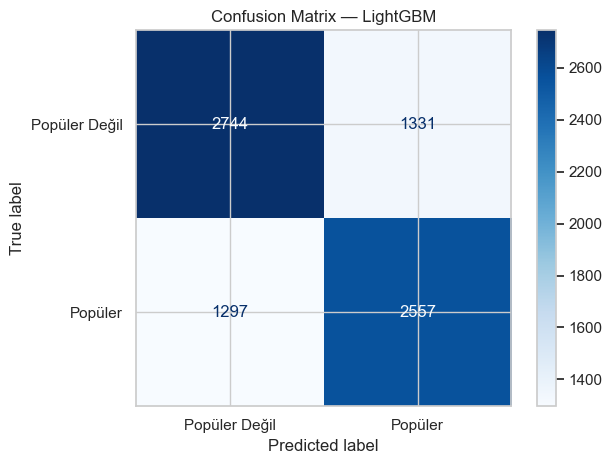

In [14]:
best_proba = df_clf[df_clf['Model'] == 'LightGBM'].iloc[0]['_proba']
cm = confusion_matrix(y_cls_test, (best_proba >= 0.5).astype(int))

ConfusionMatrixDisplay(cm, display_labels=['Popüler Değil', 'Popüler']).plot(cmap='Blues')
plt.title('Confusion Matrix — LightGBM')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

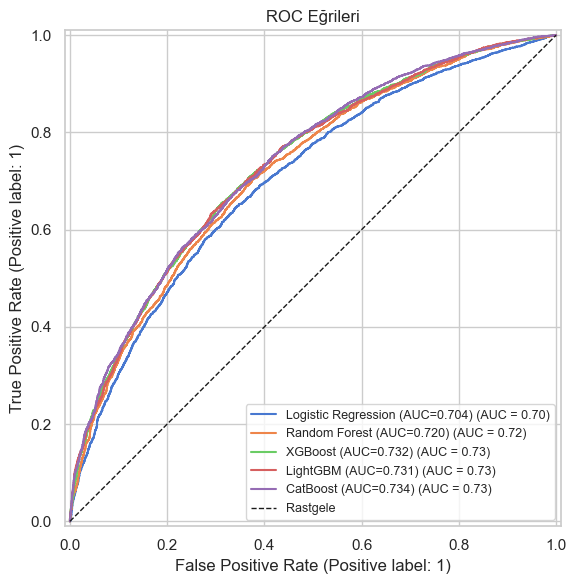

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
for _, row in df_clf.iterrows():
    RocCurveDisplay.from_predictions(
        y_cls_test, row['_proba'],
        name=f"{row['Model']} (AUC={row['AUC']:.3f})", ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele')
ax.set_title('ROC Eğrileri')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.1 Classification mı, Regression mı?

| | Regression | Classification |
|--|-----------|----------------|
| Görev | Tam sayıyı tahmin et | Popüler / Değil tahmin et |
| Metrik | RMSE ~10.970 | Accuracy ~0.66, AUC ~0.73 |

AUC 0.73 — modeller random'dan (0.50) anlamlı ölçüde iyi. Tree modelleri (LightGBM, CatBoost) öne çıkıyor.

## 10. Prescriptive Analiz — Yazar Ne Yapmalı?
Feature importance ve EDA bulgularını somut tavsiyelere dönüştürüyoruz.

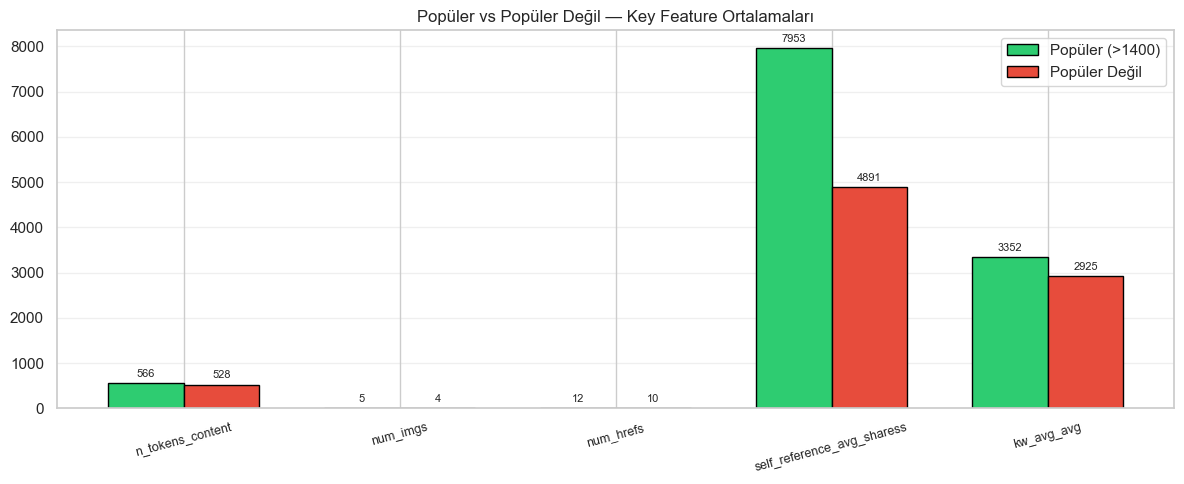

In [16]:
popular   = df[df['shares'] > THRESHOLD]
unpopular = df[df['shares'] <= THRESHOLD]

features  = ['n_tokens_content', 'num_imgs', 'num_hrefs', 'self_reference_avg_sharess', 'kw_avg_avg']
pop_means = [popular[f].mean() for f in features]
unp_means = [unpopular[f].mean() for f in features]

x, w = np.arange(len(features)), 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.bar(x - w/2, pop_means, w, label='Popüler (>1400)',   color='#2ecc71', edgecolor='black')
bu = ax.bar(x + w/2, unp_means, w, label='Popüler Değil', color='#e74c3c', edgecolor='black')
ax.bar_label(bp, fmt='%.0f', fontsize=8, padding=3)
ax.bar_label(bu, fmt='%.0f', fontsize=8, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=9, rotation=15)
ax.set_title('Popüler vs Popüler Değil — Key Feature Ortalamaları')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('prescriptive_features.png', dpi=120, bbox_inches='tight')
plt.show()

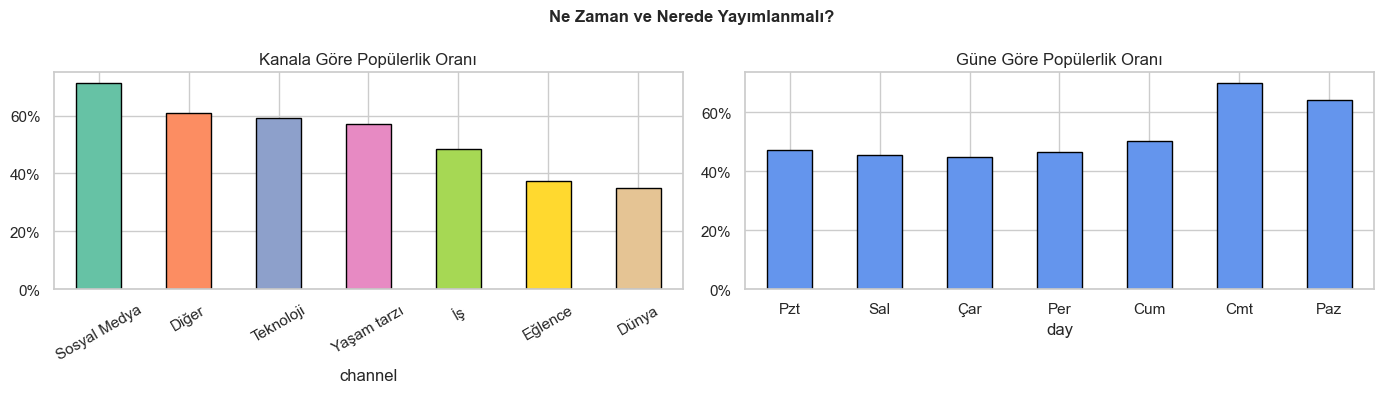

In [17]:
df['popular'] = (df['shares'] > THRESHOLD).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('channel')['popular'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color=sns.color_palette('Set2', 7), edgecolor='black')
axes[0].set_title('Kanala Göre Popülerlik Oranı')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[0].tick_params(axis='x', rotation=30)

day_order = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
df.groupby('day')['popular'].mean().reindex(day_order).plot(
    kind='bar', ax=axes[1], color='cornflowerblue', edgecolor='black')
axes[1].set_title('Güne Göre Popülerlik Oranı')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Ne Zaman ve Nerede Yayımlanmalı?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('prescriptive_channel_day.png', dpi=120, bbox_inches='tight')
plt.show()

### Tavsiyeler

| Tavsiye | Neden |
|---------|-------|
| 400–800 kelime yaz | Sweet spot — çok kısa yüzeysel, çok uzun sıkıcı |
| 4–6+ görsel ekle | `num_imgs` en güçlü feature'lardan biri |
| Kendi popüler makalelerine link ver | `self_reference_avg_sharess` çok etkili |
| Yüksek paylaşımlı keyword'ler kullan | `kw_avg_avg` en önemli tek feature |
| Hafta sonu yayımla | Daha az rekabet, daha fazla boş zaman |
| Teknoloji veya Sosyal Medya konusu seç | Bu kanallar en yüksek popularity rate'e sahip |

> **Not:** Model varyansın ~%15'ini açıklıyor. Gerisi influencer etkisi, şans — bunlar tahmin edilemez.